# Problem 1

<div style="text-align:center;">
    <img src="Problem1.png" width=600">
</div>

## Part 1
Construct the transformation matrices that describe the kinematics of the three center of mass positions
of the links.

In [73]:
import sympy as sp
from sympy import Matrix, cos, sin, simplify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Time
t = sp.symbols('t', real=True)

# Configuration variables as a function of time
x = sp.Function('x')(t)
y = sp.Function('y')(t)
theta = sp.Function('theta')(t)
alpha1 = sp.Function('alpha1')(t)
alpha2 = sp.Function('alpha2')(t)

# Constants
L1, Lb, L2 , l = sp.symbols('L1 Lb L2 l', positive=True, real=True)

q = sp.Matrix([x, y, theta, alpha1, alpha2])
qd = q.diff(t)
qdd = q.diff(t, 2)

# Helper Functions 
def cross_matrix(vec):
    
    return np.array([[0, -vec[2,0], vec[1,0]],
                   [vec[2,0], 0, -vec[0,0]],
                   [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    
    return np.array([[mat[2,1]],
                   [mat[0,2]], 
                   [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    
    return m
    
def R_z(theta):
    return np.array([[cos(theta), -sin(theta), 0], 
                   [sin(theta),  cos(theta), 0],
                   [0,           0,          1]])

def R_y(theta):
    return np.array([[cos(theta), 0, sin(theta)], 
                   [0,          1, 0],
                   [-sin(theta),0, cos(theta)]])

def R_x(theta):
    return np.array([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta),  cos(theta)]])

def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m

# World to body center
T0b = T(R_z(theta), Matrix([[x], [y], [0]]))
T_0b = simplify(T0b)

# Left link COM transform
T_center_to_left_joint = T(Matrix.eye(3), Matrix([-l/2, 0, 0]))
T_left_joint_rotation  = T(R_z(alpha1), Matrix([0, 0, 0]))
T_left_link_com_offset = T(Matrix.eye(3), Matrix([-l/2, 0, 0]))
T_01 = simplify(T_0b @ T_center_to_left_joint @ T_left_joint_rotation @ T_left_link_com_offset)

# Right link COM transform
T_center_to_right_joint = T(Matrix.eye(3), Matrix([l/2, 0, 0]))
T_right_joint_rotation  = T(R_z(alpha2), Matrix([0, 0, 0]))
T_right_link_com_offset = T(Matrix.eye(3), Matrix([l/2, 0, 0]))
T_02 = simplify(T_0b @ T_center_to_right_joint @ T_right_joint_rotation @ T_right_link_com_offset)

print("World to body center transformation matrix:")
T_0b

World to body center transformation matrix:


Matrix([
[cos(theta(t)), -sin(theta(t)), 0, x(t)],
[sin(theta(t)),  cos(theta(t)), 0, y(t)],
[            0,              0, 1,    0],
[            0,              0, 0,    1]])

In [78]:
print("Left link COM transformation matrix:")
T_01

Left link COM transformation matrix:


Matrix([
[cos(alpha1(t) + theta(t)), -sin(alpha1(t) + theta(t)), 0, -l*cos(alpha1(t) + theta(t))/2 - l*cos(theta(t))/2 + x(t)],
[sin(alpha1(t) + theta(t)),  cos(alpha1(t) + theta(t)), 0, -l*sin(alpha1(t) + theta(t))/2 - l*sin(theta(t))/2 + y(t)],
[                        0,                          0, 1,                                                         0],
[                        0,                          0, 0,                                                         1]])

In [79]:
print("Right link COM transformation matrix:")
T_02

Right link COM transformation matrix:


Matrix([
[cos(alpha2(t) + theta(t)), -sin(alpha2(t) + theta(t)), 0, l*cos(alpha2(t) + theta(t))/2 + l*cos(theta(t))/2 + x(t)],
[sin(alpha2(t) + theta(t)),  cos(alpha2(t) + theta(t)), 0, l*sin(alpha2(t) + theta(t))/2 + l*sin(theta(t))/2 + y(t)],
[                        0,                          0, 1,                                                        0],
[                        0,                          0, 0,                                                        1]])

## Part 2
Generate the body twists for these link center of masses.

In [80]:
# Body twist matrices
Vb_hat_1 = simplify(T_01.inv() @ sp.diff(T_01, t))
Vb_hat_b = simplify(T_0b.inv() @ sp.diff(T_0b, t))
Vb_hat_2 = simplify(T_02.inv() @ sp.diff(T_02, t))

# Body twist vectors
Vb_1 = twist2vec(Vb_hat_1)
Vb_b = twist2vec(Vb_hat_b)
Vb_2 = twist2vec(Vb_hat_2)

Vb_b

Matrix([
[                                                                     0],
[                                                                     0],
[                                               Derivative(theta(t), t)],
[ sin(theta(t))*Derivative(y(t), t) + cos(theta(t))*Derivative(x(t), t)],
[-sin(theta(t))*Derivative(x(t), t) + cos(theta(t))*Derivative(y(t), t)],
[                                                                     0]])

In [81]:
Vb_1

Matrix([
[                                                                                                                                                                                                                                                                 0],
[                                                                                                                                                                                                                                                                 0],
[                                                                                                                                                                                                                Derivative(alpha1(t), t) + Derivative(theta(t), t)],
[(-l*sin(2*alpha1(t) + theta(t))*Derivative(theta(t), t)/2 + l*sin(theta(t))*Derivative(theta(t), t)/2 + sin(2*alpha1(t) + 2*theta(t))*Derivative(y(t), t) + cos(2*alpha1(t) + 2*theta(t))*Derivative(x(t), t

In [82]:
Vb_2

Matrix([
[                                                                                                                                                                                                                                                                0],
[                                                                                                                                                                                                                                                                0],
[                                                                                                                                                                                                               Derivative(alpha2(t), t) + Derivative(theta(t), t)],
[(l*sin(2*alpha2(t) + theta(t))*Derivative(theta(t), t)/2 - l*sin(theta(t))*Derivative(theta(t), t)/2 + sin(2*alpha2(t) + 2*theta(t))*Derivative(y(t), t) + cos(2*alpha2(t) + 2*theta(t))*Derivative(x(t), t) + 

## Part 3
Generate the body body twist Jacobians that map pose/joint velocities into twists.

In [83]:
# Body Jacobians
Jb_1 = simplify(Vb_1.jacobian(qd))
Jb_b = simplify(Vb_b.jacobian(qd))
Jb_2 = simplify(Vb_2.jacobian(qd))

Jb_b

Matrix([
[             0,             0, 0, 0, 0],
[             0,             0, 0, 0, 0],
[             0,             0, 1, 0, 0],
[ cos(theta(t)), sin(theta(t)), 0, 0, 0],
[-sin(theta(t)), cos(theta(t)), 0, 0, 0],
[             0,             0, 0, 0, 0]])

In [84]:
Jb_1

Matrix([
[                                                                0,                                                           0,                         0,    0, 0],
[                                                                0,                                                           0,                         0,    0, 0],
[                                                                0,                                                           0,                         1,    1, 0],
[(cos(2*alpha1(t) + 2*theta(t)) + 1)/(2*cos(alpha1(t) + theta(t))), sin(2*alpha1(t) + 2*theta(t))/(2*cos(alpha1(t) + theta(t))),       -l*sin(alpha1(t))/2,    0, 0],
[                                       -sin(alpha1(t) + theta(t)),                                   cos(alpha1(t) + theta(t)), -l*(cos(alpha1(t)) + 1)/2, -l/2, 0],
[                                                                0,                                                           0,                         0,    0,

In [85]:
Jb_2

Matrix([
[                                                                0,                                                           0,                        0, 0,   0],
[                                                                0,                                                           0,                        0, 0,   0],
[                                                                0,                                                           0,                        1, 0,   1],
[(cos(2*alpha2(t) + 2*theta(t)) + 1)/(2*cos(alpha2(t) + theta(t))), sin(2*alpha2(t) + 2*theta(t))/(2*cos(alpha2(t) + theta(t))),       l*sin(alpha2(t))/2, 0,   0],
[                                       -sin(alpha2(t) + theta(t)),                                   cos(alpha2(t) + theta(t)), l*(cos(alpha2(t)) + 1)/2, 0, l/2],
[                                                                0,                                                           0,                        0, 0,   0]])

## Part 4

<div style="text-align:center;">
    <img src="Problem4.png" width=600">
</div>

In [86]:
k, l = sp.symbols('k l', positive=True, real=True)

def body_wrench(Vb, k, l):
    B = Matrix([
        [0, 0, 0,         0,    0,    0],
        [0, 0, 0,         0,    0,    0],
        [0, 0, 2*k*l**3/3,0,    0,    0],
        [0, 0, 0,         k*l,  0,    0],
        [0, 0, 0,         0,   2*k*l, 0],
        [0, 0, 0,         0,    0,    0]
    ])
    
    Fb = -B * Vb
    return Fb
    
# Body wrench vectors
Fb_1 = body_wrench(Vb_1, k, l)
Fb_b = body_wrench(Vb_b, k, l)
Fb_2 = body_wrench(Vb_2, k, l)

In [88]:
Fb_b

Matrix([
[                                                                              0],
[                                                                              0],
[                                            -2*k*l**3*Derivative(theta(t), t)/3],
[   -k*l*(sin(theta(t))*Derivative(y(t), t) + cos(theta(t))*Derivative(x(t), t))],
[-2*k*l*(-sin(theta(t))*Derivative(x(t), t) + cos(theta(t))*Derivative(y(t), t))],
[                                                                              0]])

In [95]:
Fb_1

Matrix([
[                                                                                                                                                                                                                                                                      0],
[                                                                                                                                                                                                                                                                      0],
[                                                                                                                                                                                                       -2*k*l**3*(Derivative(alpha1(t), t) + Derivative(theta(t), t))/3],
[-k*l*(-l*sin(2*alpha1(t) + theta(t))*Derivative(theta(t), t)/2 + l*sin(theta(t))*Derivative(theta(t), t)/2 + sin(2*alpha1(t) + 2*theta(t))*Derivative(y(t), t) + cos(2*alpha1(t) + 2*theta(t)

In [94]:
Fb_2

Matrix([
[                                                                                                                                                                                                                                                                     0],
[                                                                                                                                                                                                                                                                     0],
[                                                                                                                                                                                                      -2*k*l**3*(Derivative(alpha2(t), t) + Derivative(theta(t), t))/3],
[-k*l*(l*sin(2*alpha2(t) + theta(t))*Derivative(theta(t), t)/2 - l*sin(theta(t))*Derivative(theta(t), t)/2 + sin(2*alpha2(t) + 2*theta(t))*Derivative(y(t), t) + cos(2*alpha2(t) + 2*theta(t))*De

## Part 5

In [102]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def swimmer_dynamics(t, state, params):

    # State
    x_val, y_val, theta_val, a1_val, a2_val = state

    # Parameters
    k_val, l_val = params

    # Shape Velocities
    alpha_dot = gait_rates(t, A_val, phase_val)

    # Evaluate A_tilde
    A_eval = np.array(
        A_tilde_func([theta_val, a1_val, a2_val], [k_val, l_val]),
        dtype=float
    )

    # pose_dot = A_tilde * shape_dot
    pose_dot = A_eval @ alpha_dot
    
    return np.array([
        pose_dot[0],
        pose_dot[1],
        pose_dot[2],
        alpha_dot[0],
        alpha_dot[1]
    ], dtype=float)

<div style="text-align:center;">
    <img src="Problem678.png" width=600">
</div>

## Part 6

In [120]:
B = sp.Matrix([
    [0, 0, 0,         0,      0,      0],
    [0, 0, 0,         0,      0,      0],
    [0, 0, 2*k*l**3/3,0,      0,      0],
    [0, 0, 0,         k*l,    0,      0],
    [0, 0, 0,         0,    2*k*l,    0],
    [0, 0, 0,         0,      0,      0]
])

A_mat = (Jb_1.T @ B @ Jb_1) + (Jb_b.T @ B @ Jb_b) + (Jb_2.T @ B @ Jb_2)

A11 = A_mat[:3, :3]
A12 = A_mat[:3, 3:5]

A_tilde = -A11.LUsolve(A12)
A12

Matrix([
[                    1.0*k*l*sin(alpha1(t) + theta(t)),                    -1.0*k*l*sin(alpha2(t) + theta(t))],
[                   -1.0*k*l*cos(alpha1(t) + theta(t)),                     1.0*k*l*cos(alpha2(t) + theta(t))],
[0.5*k*l**2*(cos(alpha1(t)) + 1) + 0.666666666666667*k, 0.5*k*l**2*(cos(alpha2(t)) + 1) + 0.666666666666667*k]])

## Part 7

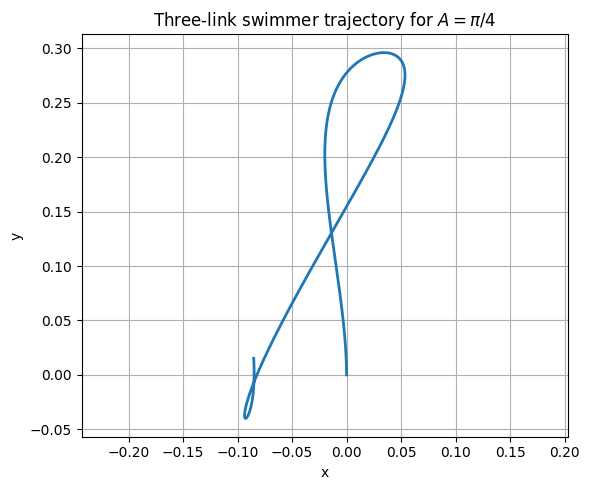

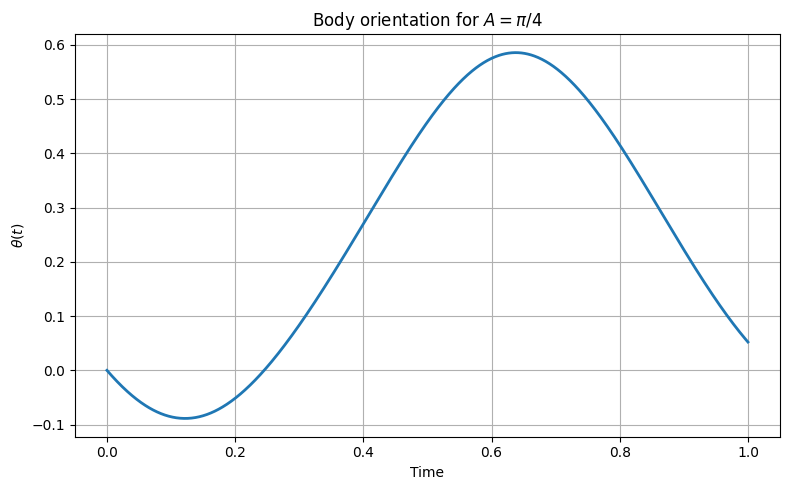

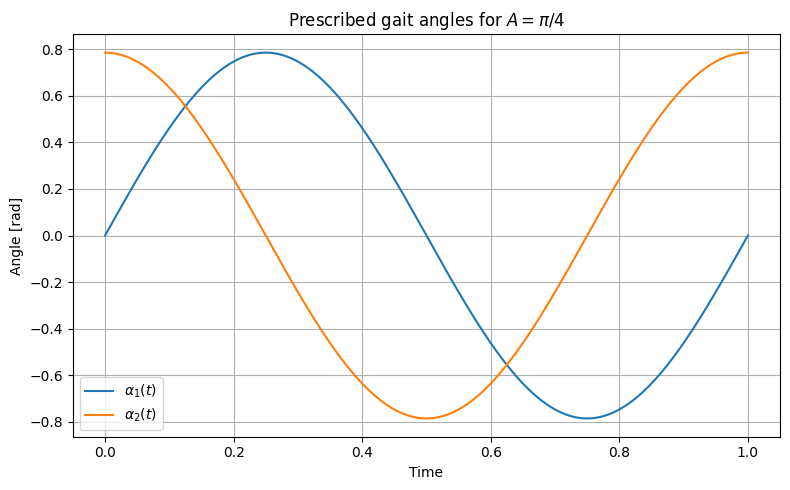

In [106]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Lambdify A_tilde
A_tilde_func = sp.lambdify(
    ([theta, alpha1, alpha2], [k, l]),
    A_tilde,
    "numpy"
)

# Gait parameters
A_val = np.pi / 4      # amplitude
phase_val = np.pi / 2  # phase difference

k_val = 1.0
l_val = 1.0

params_val = [k_val, l_val]

# Gait functions
def gait_angles(t, A, phase):
    a1_val = A * np.sin(2*np.pi*t)
    a2_val = A * np.sin(2*np.pi*t + phase)
    return a1_val, a2_val

def gait_rates(t, A, phase):
    a1d_val = 2*np.pi*A * np.cos(2*np.pi*t)
    a2d_val = 2*np.pi*A * np.cos(2*np.pi*t + phase)
    return np.array([a1d_val, a2d_val], dtype=float)

def swimmer_dynamics(t, state, params):

    # State
    x_val, y_val, theta_val, a1_val, a2_val = state

    # Parameters
    k_val, l_val = params

    # Shape Velocities
    alpha_dot = gait_rates(t, A_val, phase_val)

    # Evaluate A_tilde
    A_eval = np.array(
        A_tilde_func([theta_val, a1_val, a2_val], [k_val, l_val]),
        dtype=float
    )

    # pose_dot = A_tilde * shape_dot
    pose_dot = A_eval @ alpha_dot

    # Return [xdot, ydot, thetadot, a1dot, a2dot]
    return np.array([
        pose_dot[0],
        pose_dot[1],
        pose_dot[2],
        alpha_dot[0],
        alpha_dot[1]
    ], dtype=float)

# Initial conditions
y0 = np.array([
    0.0,
    0.0,
    0.0,
    0.0,
    0.0
], dtype=float)

t_span = (0.0, 1.0)
t_eval = np.linspace(0.0, 1.0, 1000)

sol = solve_ivp(
    fun=lambda t, y: swimmer_dynamics(t, y, params_val),
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-8,
    atol=1e-10
)

alpha1_sol, alpha2_sol = gait_angles(sol.t, A_val, phase_val)


plt.figure(figsize=(6, 5))
plt.plot(sol.y[0, :], sol.y[1, :], linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Three-link swimmer trajectory for $A=\pi/4$")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(sol.t, sol.y[2, :], linewidth=2)
plt.xlabel("Time")
plt.ylabel(r"$\theta(t)$")
plt.title(r"Body orientation for $A=\pi/4$")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(sol.t, alpha1_sol, label=r"$\alpha_1(t)$")
plt.plot(sol.t, alpha2_sol, label=r"$\alpha_2(t)$")
plt.xlabel("Time")
plt.ylabel("Angle [rad]")
plt.title(r"Prescribed gait angles for $A=\pi/4$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Part 8

Best amplitude A: 1.8849555921538759
Best distance traveled: 0.10111297615526774


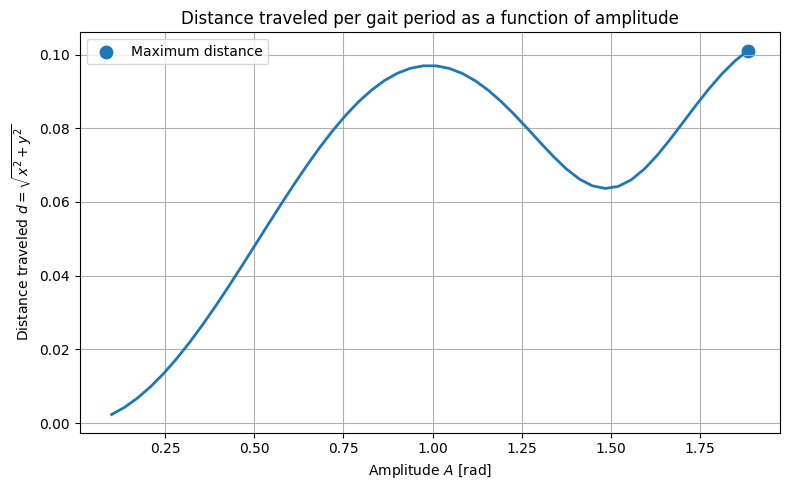

In [107]:
# Sweep A from 0.1 to 1.2*pi/2
A_values = np.linspace(0.1, 1.2*np.pi/2, 50)

distances = []
x_final_values = []
y_final_values = []

# Initial conditions [x, y, theta, alpha1, alpha2]
y0 = np.array([0, 0, 0, 0, 0], dtype=float)

# One gait period
t_span = (0.0, 1.0)
t_eval = np.linspace(0.0, 1.0, 500)

for A_test in A_values:

    # Temporarily update global amplitude used inside swimmer_dynamics
    A_val = A_test

    sol = solve_ivp(
        fun=lambda t, y: swimmer_dynamics(t, y, params_val),
        t_span=t_span,
        y0=y0,
        t_eval=t_eval,
        method="RK45",
        rtol=1e-8,
        atol=1e-10
    )

    x_final = sol.y[0, -1]
    y_final = sol.y[1, -1]

    distance = np.sqrt(x_final**2 + y_final**2)

    x_final_values.append(x_final)
    y_final_values.append(y_final)
    distances.append(distance)

# Convert to numpy arrays
distances = np.array(distances)
x_final_values = np.array(x_final_values)
y_final_values = np.array(y_final_values)

# Find best amplitude
best_index = np.argmax(distances)
best_A = A_values[best_index]
best_distance = distances[best_index]

print("Best amplitude A:", best_A)
print("Best distance traveled:", best_distance)

# Plot distance traveled as a function of A
plt.figure(figsize=(8, 5))
plt.plot(A_values, distances, linewidth=2)
plt.scatter(best_A, best_distance, s=80, label="Maximum distance")
plt.xlabel(r"Amplitude $A$ [rad]")
plt.ylabel(r"Distance traveled $d = \sqrt{x^2 + y^2}$")
plt.title("Distance traveled per gait period as a function of amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Problem 2

## Part 1
Write a Python function that takes a body twist vector and returns the body wrench from sliding snake-skin friction

In [108]:
import numpy as np

def snake_skin_wrench(Vb, f_parallel=1.0, f_perp=1.0):
    """
    Takes a body twist Vb = [omega, vx, vy]
    and returns body wrench Fb = [torque, Fx, Fy]
    from snake-skin sliding friction.
    """

    omega = Vb[0]
    vx = Vb[1]
    vy = Vb[2]

    # Parallel friction depends on direction of x sliding
    if vx < 0:
        Fx = -2 * f_parallel * np.sign(vx)
    elif vx > 0:
        Fx = -1 * f_parallel * np.sign(vx)
    else:
        Fx = 0

    # Perpendicular friction
    if vy != 0:
        Fy = -f_perp * np.sign(vy)
    else:
        Fy = 0

    # No rotational friction given directly
    torque = 0

    return np.array([torque, Fx, Fy])

## Part 2
Write a function that takes in the configuration variables of the three-link swimmer and returns the net force from snake-skin friction

In [111]:
import numpy as np

def R(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

def adjoint_SE2(theta, p):
    """
    Planar adjoint for twist order:
    V = [omega, vx, vy]
    """
    Rot = R(theta)

    Ad = np.array([
        [1,       0,          0],
        [p[1],    Rot[0, 0],  Rot[0, 1]],
        [-p[0],   Rot[1, 0],  Rot[1, 1]]
    ])

    return Ad

def net_snake_friction(q, qdot, l=1.0, f_parallel=1.0, f_perp=1.0):
    """
    Computes total snake-skin friction wrench on a 3-link snake.

    q = [x, y, theta, alpha1, alpha2]
    qdot = [xdot, ydot, thetadot, alpha1dot, alpha2dot]

    Returns:
        F_net = [net torque, net Fx, net Fy]
        expressed in the middle link/body frame
    """

    x, y, theta, alpha1, alpha2 = q
    xdot, ydot, thetadot, alpha1dot, alpha2dot = qdot

    # Base/body twist of middle link
    Vb = np.array([thetadot, xdot, ydot])

    # Middle link
    V_middle = Vb
    F_middle = snake_skin_wrench(V_middle, f_parallel, f_perp)

    # Front link
    p_front = np.array([l, 0])
    theta_front = alpha1

    Ad_front = adjoint_SE2(theta_front, p_front)

    V_front = Ad_front @ Vb + np.array([alpha1dot, 0, 0])
    F_front_local = snake_skin_wrench(V_front, f_parallel, f_perp)

    # Convert front link wrench back to middle body frame
    F_front = Ad_front.T @ F_front_local

    # Back link
    p_back = np.array([-l, 0])
    theta_back = alpha2

    Ad_back = adjoint_SE2(theta_back, p_back)

    V_back = Ad_back @ Vb + np.array([alpha2dot, 0, 0])
    F_back_local = snake_skin_wrench(V_back, f_parallel, f_perp)

    # Convert back link wrench back to middle body frame
    F_back = Ad_back.T @ F_back_local

    # Net force 
    F_net = F_middle + F_front + F_back

    return F_net


## Part 3
Using the fsolve function in Python, solve for the swimmer velocity one instance in time using a random initial configuration, and random joint velocities

In [116]:
from scipy.optimize import fsolve
import numpy as np

# Random configuration
q = np.array([
    0.0,   # x
    0.0,   # y
    0.3,   # theta
    0.5,   # alpha1
   -0.4    # alpha2
])

# Random joint velocities
alpha1dot = 1.2
alpha2dot = -0.8

def force_balance_unknown_velocity(V_unknown):
    """
    V_unknown = [xdot, ydot, thetadot]
    """

    xdot, ydot, thetadot = V_unknown

    qdot = np.array([
        xdot,
        ydot,
        thetadot,
        alpha1dot,
        alpha2dot
    ])

    F_net = net_snake_friction(q, qdot)

    return F_net


# Initial guess for [xdot, ydot, thetadot]
V_guess = np.array([0.0, 0.0, 0.0])

# Solve force balance
V_solution = fsolve(force_balance_unknown_velocity, V_guess)

print("Solved swimmer velocity:")
print("xdot     =", V_solution[0])
print("ydot     =", V_solution[1])
print("thetadot =", V_solution[2])

# Check net force at solution
F_check = force_balance_unknown_velocity(V_solution)

print("\nNet force check:")
print(F_check)

Solved swimmer velocity:
xdot     = 0.0
ydot     = 0.0
thetadot = 0.0

Net force check:
[0. 0. 0.]


## Part 4
Wrap your fsolve based solver for the floating base velocity, in a python function that takes in time and state variable. Call this dynamics function with solve_ivp to numerically integrate for the locomotion of the snake with a sinusoidal gait

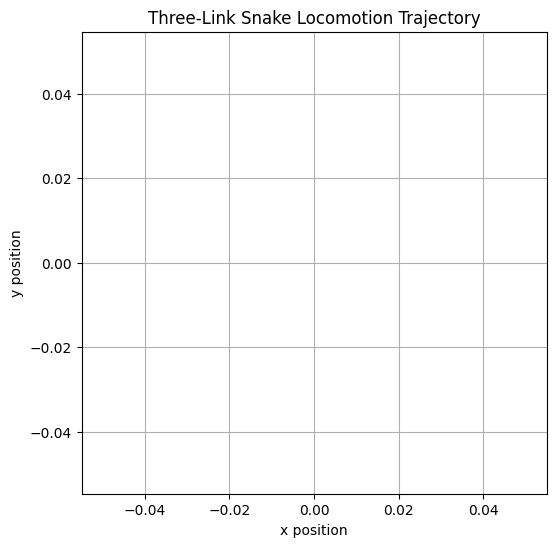

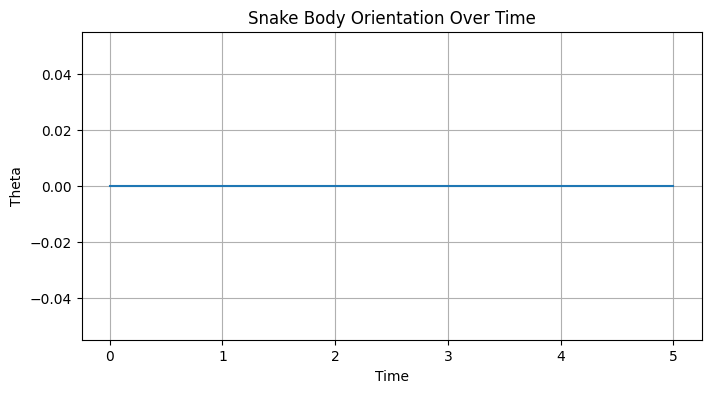

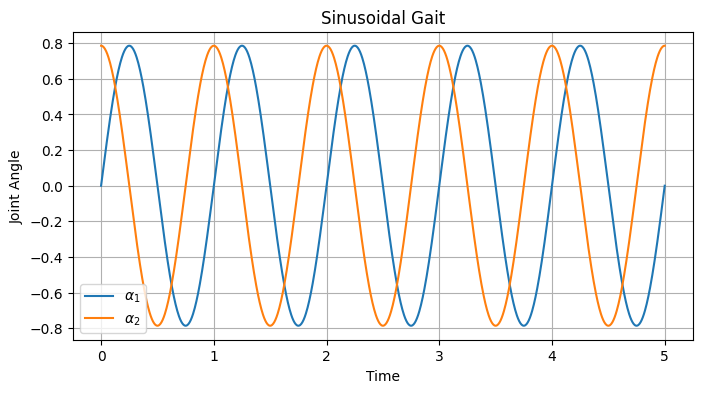

In [117]:
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import numpy as np
import matplotlib.pyplot as plt

A = np.pi / 4        # amplitude
omega = 2 * np.pi    # frequency
phase = np.pi / 2    # phase shift

l = 1.0
f_parallel = 1.0
f_perp = 2.0


def gait_angles(t):
    alpha1 = A * np.sin(omega * t)
    alpha2 = A * np.sin(omega * t + phase)

    return alpha1, alpha2


def gait_rates(t):
    alpha1dot = A * omega * np.cos(omega * t)
    alpha2dot = A * omega * np.cos(omega * t + phase)

    return alpha1dot, alpha2dot
    
def snake_dynamics(t, state):
    """
    state = [x, y, theta]

    Returns:
        [xdot, ydot, thetadot]
    """

    x, y, theta = state

    alpha1, alpha2 = gait_angles(t)
    alpha1dot, alpha2dot = gait_rates(t)

    q = np.array([x, y, theta, alpha1, alpha2])

    def force_balance(V_unknown):
        """
        V_unknown = [xdot, ydot, thetadot]
        """

        xdot, ydot, thetadot = V_unknown

        qdot = np.array([
            xdot,
            ydot,
            thetadot,
            alpha1dot,
            alpha2dot
        ])

        F_net = net_snake_friction(
            q,
            qdot,
            l=l,
            f_parallel=f_parallel,
            f_perp=f_perp
        )

        return F_net

    # Initial guess for fsolve
    V_guess = np.array([0.0, 0.0, 0.0])

    # Solve for floating base velocity
    V_solution = fsolve(force_balance, V_guess)

    return V_solution

# Initial condition
state0 = np.array([
    0.0,   # x
    0.0,   # y
    0.0    # theta
])

# Simulate for 5 gait cycles
t_span = (0, 5)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

sol = solve_ivp(
    snake_dynamics,
    t_span,
    state0,
    t_eval=t_eval,
    rtol=1e-6,
    atol=1e-8
)

x_vals = sol.y[0]
y_vals = sol.y[1]
theta_vals = sol.y[2]

plt.figure(figsize=(6, 6))
plt.plot(x_vals, y_vals)
plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Three-Link Snake Locomotion Trajectory")
plt.axis("equal")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(sol.t, theta_vals)
plt.xlabel("Time")
plt.ylabel("Theta")
plt.title("Snake Body Orientation Over Time")
plt.grid(True)
plt.show()

alpha1_vals = []
alpha2_vals = []

for t in sol.t:
    a1, a2 = gait_angles(t)
    alpha1_vals.append(a1)
    alpha2_vals.append(a2)

plt.figure(figsize=(8, 4))
plt.plot(sol.t, alpha1_vals, label=r"$\alpha_1$")
plt.plot(sol.t, alpha2_vals, label=r"$\alpha_2$")
plt.xlabel("Time")
plt.ylabel("Joint Angle")
plt.title("Sinusoidal Gait")
plt.legend()
plt.grid(True)
plt.show()